In [1]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from qiskit.quantum_info import SparsePauliOp
from collections import Counter
from fcc import ProteinShapeDecoder, ProteinShapeFileGen
from fcc.fcc_protein_shape import turns_to_bitstring
from fcc.measurement_utils import _evaluate_sparsepauli
from fcc.fcc_peptide import Peptide

2025-05-29 19:56:16,361	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]


# Function to load the qubit_op from the existing directory

def load_qubit_op(main_seq, r2_threshold, ham_dir="fcc_hamilts"):
    """
    Load the Hamiltonian operator from a JSON file.
    
    Args:
        main_seq (str): The amino acid sequence (e.g., "KLVFFA")
        r2_threshold (float): Threshold for R2 filtering
        ham_dir (str): Directory where the Hamiltonian is stored
    
    Returns:
        SparsePauliOp: The qubit Hamiltonian operator
    """
    file_name = f"{main_seq}_{len(main_seq)}AAs_R2_{int(r2_threshold * 1000)}.json"
    os.makedirs(ham_dir, exist_ok=True)
    file_path = os.path.join(ham_dir, file_name)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Hamiltonian not found at: {file_path}")
    
    print(f"✅ Loaded Hamiltonian from: {file_path}")
    
    with open(file_path, "r") as f:
        data = json.load(f)
        num_qubits = data["num_qubits"]
        sparse_op_list = [(label, coeff) for label, coeff in data["sparse_list"]]
    
    qubit_op = SparsePauliOp.from_list(sparse_op_list, num_qubits=num_qubits)
    return qubit_op

Load the problem Hamiltonian

In [5]:
main_seq="KLVFFA"
qubit_op = load_qubit_op(main_seq, r2_threshold=1.0)
print(qubit_op.size)

✅ Loaded Hamiltonian from: fcc_hamilts/KLVFFA_6AAs_R2_1000.json
18133


In [6]:
# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:100]
top_cls_solns[:10]

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33]]

# Load VQEC sampler results ibm_cleveland, R2=1

There are a total of 49626 bitstrings.
✅ Loaded 30051 valid bitstrings.
❌ Dropped 19575 unphysical turn sequences (with 'x').


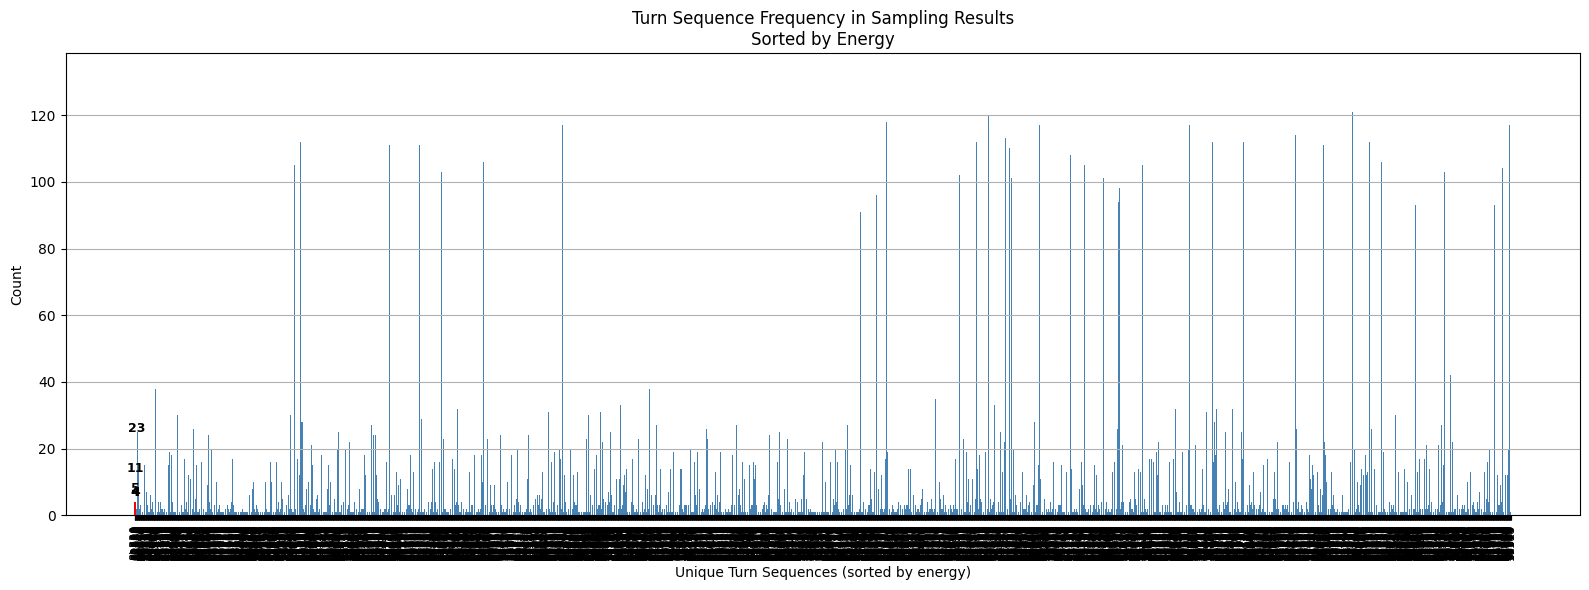

✅ Saved energy+count dictionary to cleveland_vqec_sampled_energy_dict.json


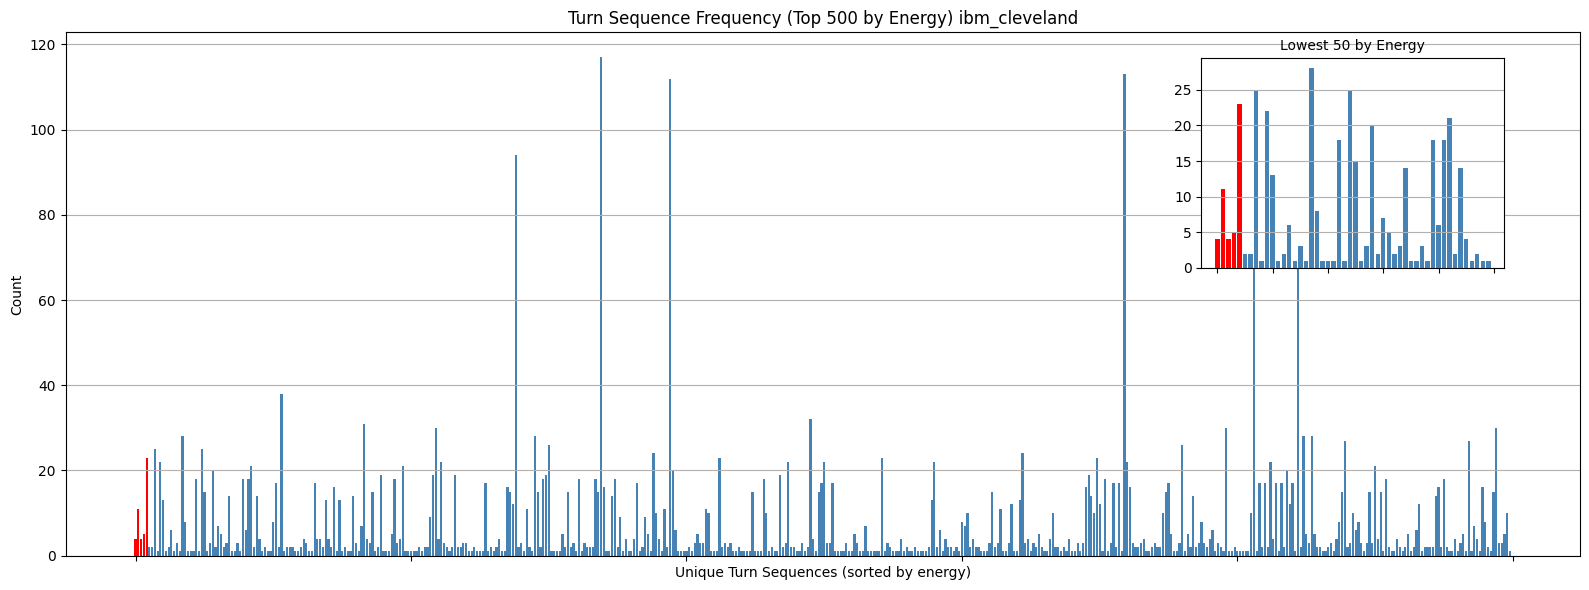

In [10]:
# Path to the folder with saved sampling results using opt parameters from data/protein-folding-qc/res/vqec_hw/KLVFFA_2025-05-27-23-06-49_ibm_cleveland_sampled
base_dir = "../res/vqec_hw/KLVFFA_2025-05-27-23-06-49_ibm_cleveland_sampled"

# Full paths to the JSON files
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Load sampling results
with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")

main_seq = metadata["main_seq"]

turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")


# Top classical solutions to highlight
top_cls_turns = ['97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580']
cls_turn_set = set(top_cls_turns)

# Step 1: Convert turn sequences and collect energies
turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
bitstrings = [bitstring for _, bitstring, _ in turn_seq_triplets]

# Rebuild peptide and compute corrected bitstrings
peptide = Peptide(main_seq)
correct_bitstrings = [ProteinShapeDecoder(peptide, b).correct_bitstring for b in bitstrings]
energies = [_evaluate_sparsepauli(bs, qubit_op) for bs in correct_bitstrings]

# Step 2: Build mapping from turn_str -> energy (lowest energy encountered for that turn)
turn_energy_dict = {}
for turn, energy in zip(turn_strs, energies):
    if turn not in turn_energy_dict:
        turn_energy_dict[turn] = energy
    else:
        turn_energy_dict[turn] = min(turn_energy_dict[turn], energy)

# Step 3: Count occurrences
turn_counts = Counter(turn_strs)

# Step 4: Sort turn sequences by energy
sorted_turns = sorted(turn_counts.keys(), key=lambda t: turn_energy_dict[t])
x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[t] for t in sorted_turns]

# Step 5: Set bar colors
bar_colors = ['red' if t in cls_turn_set else 'steelblue' for t in sorted_turns]

# Step 6: Plot
plt.figure(figsize=(16, 6))
bars = plt.bar(x_vals, y_vals, color=bar_colors)

# Annotate red bars
for idx, turn in enumerate(sorted_turns):
    if turn in cls_turn_set:
        count = turn_counts[turn]
        plt.text(x_vals[idx], y_vals[idx] + 1, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
plt.xlabel("Unique Turn Sequences (sorted by energy)")
plt.ylabel("Count")
plt.title("Turn Sequence Frequency in Sampling Results\nSorted by Energy")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

output_path = "cleveland_vqec_sampled_energy_dict.json"

# Save both energy and count for each turn
save_dict = {
    k: {
        "energy": float(turn_energy_dict[k]),
        "count": turn_counts[k]
    }
    for k in turn_energy_dict
}

with open(output_path, "w") as f:
    json.dump(save_dict, f, indent=2)

print(f"✅ Saved energy+count dictionary to {output_path}")


with open("cleveland_vqec_sampled_energy_dict.json", "r") as f:
    sampled_data = json.load(f)

# Extract separately
turn_energy_dict = {k: v["energy"] for k, v in sampled_data.items()}
turn_counts = {k: v["count"] for k, v in sampled_data.items()}


# --- Configurable parameters ---
main_plot_limit = 500  # how many bars to show in the main plot
inset_size = 50        # how many bars to show in the inset

# --- Step 1: Sort turn sequences by energy ---
sorted_turns = sorted(turn_energy_dict.keys(), key=lambda t: turn_energy_dict[t])
sorted_turns = sorted_turns[:main_plot_limit]  # Limit for main plot

x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[t] for t in sorted_turns]

# --- Step 2: Color bars ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Main plot ---
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(x_vals, y_vals, color=bar_colors)
ax.set_ylabel("Count")
ax.set_xlabel("Unique Turn Sequences (sorted by energy)")
ax.set_title(f"Turn Sequence Frequency (Top {main_plot_limit} by Energy) ibm_cleveland")
ax.grid(True, axis='y')
ax.tick_params(labelbottom=False)  # Hide x-axis labels

# --- Inset plot ---
inset_ax = ax.inset_axes([0.75, 0.55, 0.2, 0.4])
x_inset = list(range(min(inset_size, len(sorted_turns))))
y_inset = y_vals[:inset_size]
colors_inset = bar_colors[:inset_size]
inset_ax.bar(x_inset, y_inset, color=colors_inset)
inset_ax.set_title(f"Lowest {inset_size} by Energy", fontsize=10)
inset_ax.tick_params(labelbottom=False)
inset_ax.grid(True, axis='y')

plt.tight_layout()
plt.show()



# VQEC sampling results from ibm_kingston, R2=1

There are a total of 8073 bitstrings.
✅ Loaded 7154 valid bitstrings.
❌ Dropped 919 unphysical turn sequences (with 'x').


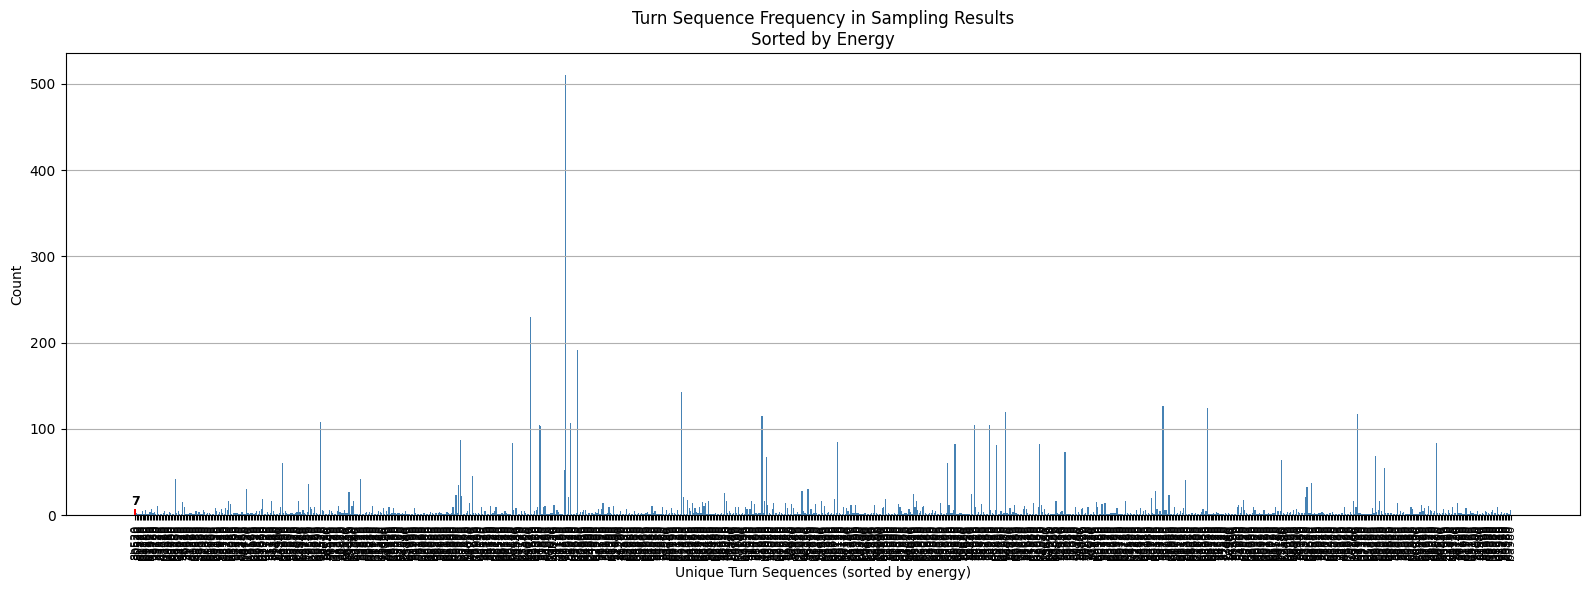

✅ Saved energy+count dictionary to ibm_kingston_vqec_sampled_energy_dict.json


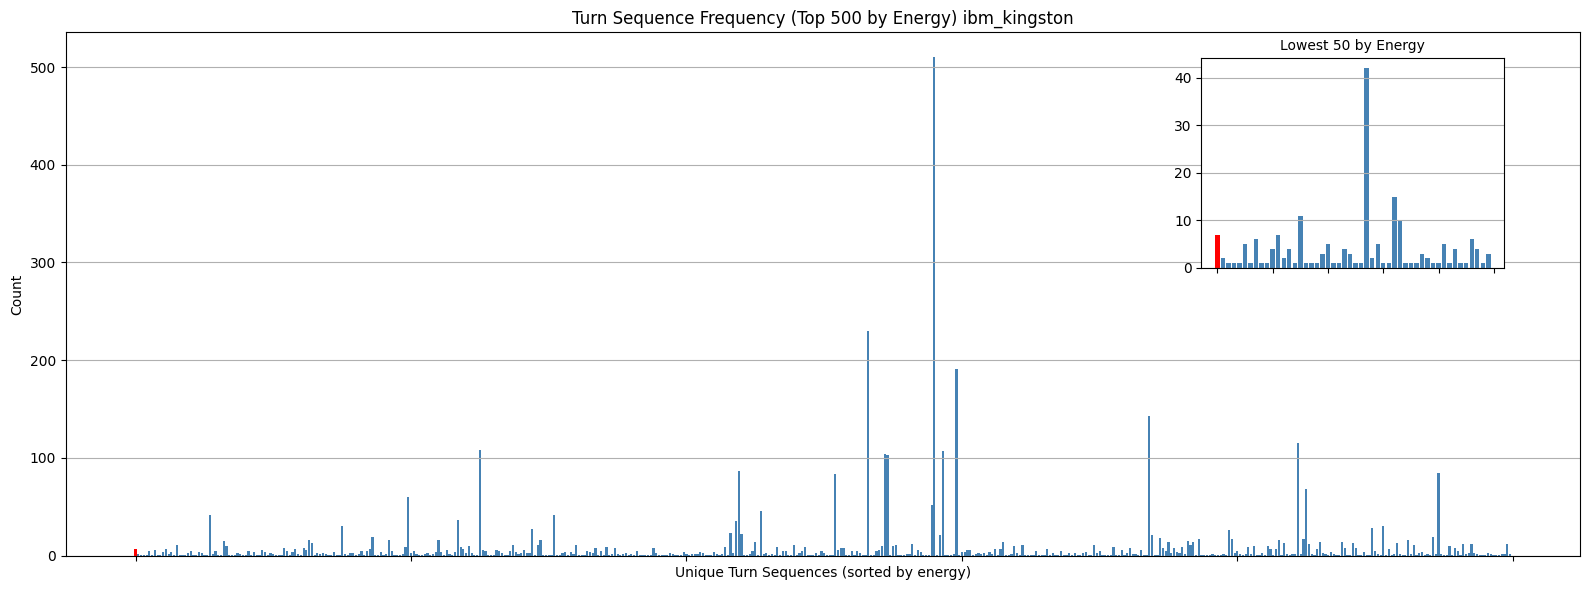

In [9]:
# Path to the folder with saved sampling results using opt parameters from data/protein-folding-qc/res/vqec_hw/KLVFFA_2025-05-23-18-26-55_ibm_kingston_sampled
base_dir = "../res/vqec_hw/KLVFFA_2025-05-23-18-26-55_ibm_kingston_sampled"

# Full paths to the JSON files
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Load sampling results
with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")

main_seq = metadata["main_seq"]

turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")


# Top classical solutions to highlight
top_cls_turns = ['97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580']
cls_turn_set = set(top_cls_turns)

# Step 1: Convert turn sequences and collect energies
turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
bitstrings = [bitstring for _, bitstring, _ in turn_seq_triplets]

# Rebuild peptide and compute corrected bitstrings
peptide = Peptide(main_seq)
correct_bitstrings = [ProteinShapeDecoder(peptide, b).correct_bitstring for b in bitstrings]
energies = [_evaluate_sparsepauli(bs, qubit_op) for bs in correct_bitstrings]

# Step 2: Build mapping from turn_str -> energy (lowest energy encountered for that turn)
turn_energy_dict = {}
for turn, energy in zip(turn_strs, energies):
    if turn not in turn_energy_dict:
        turn_energy_dict[turn] = energy
    else:
        turn_energy_dict[turn] = min(turn_energy_dict[turn], energy)

# Step 3: Count occurrences
turn_counts = Counter(turn_strs)

# Step 4: Sort turn sequences by energy
sorted_turns = sorted(turn_counts.keys(), key=lambda t: turn_energy_dict[t])
x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[t] for t in sorted_turns]

# Step 5: Set bar colors
bar_colors = ['red' if t in cls_turn_set else 'steelblue' for t in sorted_turns]

# Step 6: Plot
plt.figure(figsize=(16, 6))
bars = plt.bar(x_vals, y_vals, color=bar_colors)

# Annotate red bars
for idx, turn in enumerate(sorted_turns):
    if turn in cls_turn_set:
        count = turn_counts[turn]
        plt.text(x_vals[idx], y_vals[idx] + 1, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
plt.xlabel("Unique Turn Sequences (sorted by energy)")
plt.ylabel("Count")
plt.title("Turn Sequence Frequency in Sampling Results\nSorted by Energy")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

output_path = "ibm_kingston_vqec_sampled_energy_dict.json"

# Save both energy and count for each turn
save_dict = {
    k: {
        "energy": float(turn_energy_dict[k]),
        "count": turn_counts[k]
    }
    for k in turn_energy_dict
}

with open(output_path, "w") as f:
    json.dump(save_dict, f, indent=2)

print(f"✅ Saved energy+count dictionary to {output_path}")


with open("ibm_kingston_vqec_sampled_energy_dict.json", "r") as f:
    sampled_data = json.load(f)

# Extract separately
turn_energy_dict = {k: v["energy"] for k, v in sampled_data.items()}
turn_counts = {k: v["count"] for k, v in sampled_data.items()}


# --- Configurable parameters ---
main_plot_limit = 500  # how many bars to show in the main plot
inset_size = 50        # how many bars to show in the inset

# --- Step 1: Sort turn sequences by energy ---
sorted_turns = sorted(turn_energy_dict.keys(), key=lambda t: turn_energy_dict[t])
sorted_turns = sorted_turns[:main_plot_limit]  # Limit for main plot

x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[t] for t in sorted_turns]

# --- Step 2: Color bars ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Main plot ---
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(x_vals, y_vals, color=bar_colors)
ax.set_ylabel("Count")
ax.set_xlabel("Unique Turn Sequences (sorted by energy)")
ax.set_title(f"Turn Sequence Frequency (Top {main_plot_limit} by Energy) ibm_kingston")
ax.grid(True, axis='y')
ax.tick_params(labelbottom=False)  # Hide x-axis labels

# --- Inset plot ---
inset_ax = ax.inset_axes([0.75, 0.55, 0.2, 0.4])
x_inset = list(range(min(inset_size, len(sorted_turns))))
y_inset = y_vals[:inset_size]
colors_inset = bar_colors[:inset_size]
inset_ax.bar(x_inset, y_inset, color=colors_inset)
inset_ax.set_title(f"Lowest {inset_size} by Energy", fontsize=10)
inset_ax.tick_params(labelbottom=False)
inset_ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

